# NIKHIL TEST

In [1]:
# %%
# 
import torch
import matplotlib.pyplot as plt
import sys
from neuralop.models import FNO
from neuralop import Trainer
from neuralop.training import AdamW
from neuralop.data.datasets import load_darcy_flow_small
from neuralop.utils import count_model_params
from neuralop import LpLoss, H1Loss

device = 'cpu'


In [2]:
# Loading the Navier-Stokes dataset in 128x128 resolution
train_loader, test_loaders, data_processor = load_darcy_flow_small(
        n_train=1000, batch_size=32, 
        test_resolutions=[16, 32], n_tests=[100, 50],
        test_batch_sizes=[32, 32],
)

Loading test db for resolution 16 with 100 samples 
Loading test db for resolution 32 with 50 samples 


/home/jingpei/Documents/arclab/neuraloperator/neuralop/data/datasets/pt_dataset.py:99: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(
/home/jingpei/Documen

In [3]:
dims = 2
n_modes = tuple(dims * [16])
in_channels = 3 #1

print("N modes:", n_modes)
model = FNO(n_modes=n_modes,
             in_channels=in_channels, 
             out_channels=1, 
             hidden_channels=32, 
             projection_channel_ratio=2, 
             factorization='tucker', 
             rank=0.42)

N modes: (16, 16)


In [4]:
# Get single datapoint
batch = next(iter(train_loader))
print("x shape: ", batch['x'].shape)
print("y shape: ", batch['y'].shape)

x shape:  torch.Size([32, 1, 16, 16])
y shape:  torch.Size([32, 1, 16, 16])


In [5]:
new_x_batch = batch['x'].to(device)
new_y_batch = batch['y'].to(device)

print("new x_batch shape: ", new_x_batch.shape)
print("new y_batch shape: ", new_y_batch.shape)
# Create a tensor of shape [32, 2, 16, 16] filled with 2s
extra = torch.full((new_x_batch.shape[0], 2, new_x_batch.shape[2], new_x_batch.shape[3]), 2.0, device=new_x_batch.device, dtype=new_x_batch.dtype)
print("extra shape: ", extra.shape)
# Concatenate along the channel dimension (dim=1) to get shape [32, 3, 16, 16]
new_x_batch = torch.cat([new_x_batch, extra], dim=1)
print("new x_batch new shape: ", new_x_batch.shape)

print("sample: ", new_x_batch[0, :, 0, 0])
new_batch = {'x': new_x_batch, 'y': new_y_batch}


new x_batch shape:  torch.Size([32, 1, 16, 16])
new y_batch shape:  torch.Size([32, 1, 16, 16])
extra shape:  torch.Size([32, 2, 16, 16])
new x_batch new shape:  torch.Size([32, 3, 16, 16])
sample:  tensor([1., 2., 2.])


In [6]:
# out = model.forward(batch['x'])
print("new_batch['x'] shape: ", new_batch['x'].shape)
out = model.forward(new_batch['x'])

new_batch['x'] shape:  torch.Size([32, 3, 16, 16])


In [7]:
print("out shape: ", out.shape)

out shape:  torch.Size([32, 1, 16, 16])


# OLD

In [8]:




# %%
# We create an FNO model



model = model.to(device)

n_params = count_model_params(model)
print(f'\nOur model has {n_params} parameters.')
sys.stdout.flush()


# %%
#Create the optimizer
optimizer = AdamW(model.parameters(), 
                                lr=8e-3, 
                                weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)


# %%
# Creating the losses
l2loss = LpLoss(d=2, p=2)
h1loss = H1Loss(d=2)

train_loss = h1loss
eval_losses={'h1': h1loss, 'l2': l2loss}


# %%


print('\n### MODEL ###\n', model)
print('\n### OPTIMIZER ###\n', optimizer)
print('\n### SCHEDULER ###\n', scheduler)
print('\n### LOSSES ###')
print(f'\n * Train: {train_loss}')
print(f'\n * Test: {eval_losses}')
sys.stdout.flush()


# %% 
# Create the trainer
trainer = Trainer(model=model, n_epochs=20,
                  device=device,
                  data_processor=data_processor,
                  wandb_log=False,
                  eval_interval=3,
                  use_distributed=False,
                  verbose=True)


# %%
# Actually train the model on our small Darcy-Flow dataset

trainer.train(train_loader=train_loader,
              test_loaders={},
              optimizer=optimizer,
              scheduler=scheduler, 
              regularizer=False, 
              training_loss=train_loss, 
              save_every=1,
              save_dir="./NIKHIL_TEST_checkpoints")




Our model has 520889 parameters.

### MODEL ###
 FNO(
  (positional_embedding): GridEmbeddingND()
  (fno_blocks): FNOBlocks(
    (convs): ModuleList(
      (0-3): 4 x SpectralConv(
        (weight): TuckerTensor(shape=(32, 32, 16, 9), rank=(26, 26, 13, 7))
      )
    )
    (fno_skips): ModuleList(
      (0-3): 4 x Flattened1dConv(
        (conv): Conv1d(32, 32, kernel_size=(1,), stride=(1,), bias=False)
      )
    )
    (channel_mlp): ModuleList(
      (0-3): 4 x ChannelMLP(
        (fcs): ModuleList(
          (0): Conv1d(32, 16, kernel_size=(1,), stride=(1,))
          (1): Conv1d(16, 32, kernel_size=(1,), stride=(1,))
        )
      )
    )
    (channel_mlp_skips): ModuleList(
      (0-3): 4 x SoftGating()
    )
  )
  (lifting): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(5, 64, kernel_size=(1,), stride=(1,))
      (1): Conv1d(64, 32, kernel_size=(1,), stride=(1,))
    )
  )
  (projection): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(32, 64, kernel_size=(1,), s

RuntimeError: Given groups=1, weight of size [64, 5, 1], expected input[32, 3, 256] to have 5 channels, but got 3 channels instead

In [ ]:
# .. resume_from_dir:
# resume training from saved checkpoint at epoch 10

trainer = Trainer(model=model, n_epochs=20,
                  device=device,
                  data_processor=data_processor,
                  wandb_log=False,
                  eval_interval=3,
                  use_distributed=False,
                  verbose=True)

trainer.train(train_loader=train_loader,
              test_loaders={},
              optimizer=optimizer,
              scheduler=scheduler, 
              regularizer=False, 
              training_loss=train_loss,
              resume_from_dir="./NIKHIL_TEST_checkpoints")

RuntimeError: Error(s) in loading state_dict for FNO:
	Missing key(s) in state_dict: "fno_blocks.convs.0.weight.tensor", "fno_blocks.convs.1.weight.tensor", "fno_blocks.convs.2.weight.tensor", "fno_blocks.convs.3.weight.tensor". 
	Unexpected key(s) in state_dict: "fno_blocks.convs.0.weight.core", "fno_blocks.convs.0.weight.factors.factor_0", "fno_blocks.convs.0.weight.factors.factor_1", "fno_blocks.convs.0.weight.factors.factor_2", "fno_blocks.convs.0.weight.factors.factor_3", "fno_blocks.convs.1.weight.core", "fno_blocks.convs.1.weight.factors.factor_0", "fno_blocks.convs.1.weight.factors.factor_1", "fno_blocks.convs.1.weight.factors.factor_2", "fno_blocks.convs.1.weight.factors.factor_3", "fno_blocks.convs.2.weight.core", "fno_blocks.convs.2.weight.factors.factor_0", "fno_blocks.convs.2.weight.factors.factor_1", "fno_blocks.convs.2.weight.factors.factor_2", "fno_blocks.convs.2.weight.factors.factor_3", "fno_blocks.convs.3.weight.core", "fno_blocks.convs.3.weight.factors.factor_0", "f

In [ ]:
import torch 

grid_states_path = "/media/jingpei/DATA/fno_gp_data/000_grid_states.pt"
grid_states = torch.load(grid_states_path, weights_only=False)
print(grid_states.shape)

(41, 41, 41, 41, 4)


In [ ]:
from copy import deepcopy

init_grid = grid_states[:, :, 0, 0, :2]
last_grid = grid_states[:, :, :, :, 2:]
reconstructed_grid = deepcopy(init_grid)
reconstructed_grid = reconstructed_grid.view(41, 41, 1, 1, 2).expand_dims(1, 1, 41, 41, 1)
reconst

torch.Size([41, 41])


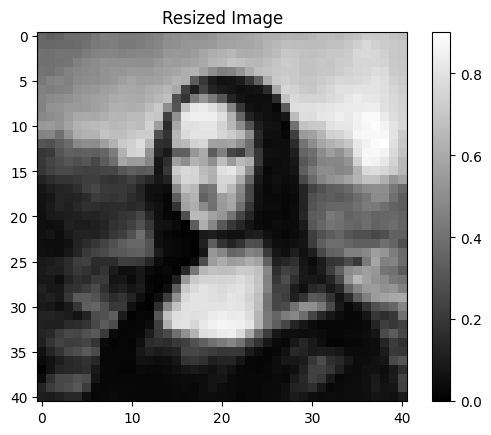

In [ ]:
from PIL import Image
import torch
import numpy as np
import matplotlib.pyplot as plt

# Load a random image
image_path = '/home/jingpei/Desktop/random_image.jpeg'  # Replace with the path to your image
image = Image.open(image_path).convert('L')  # Convert to grayscale

# Resize the image to 41x41
image_resized = image.resize((41, 41))

# Convert the image to a numpy array and then to a torch tensor
image_array = np.array(image_resized, dtype=np.float32) / 255.0  # Normalize pixel values to [0, 1]
image_tensor = torch.tensor(image_array)

# Reshape to 41x41
image_tensor = image_tensor.view(41, 41)

print(image_tensor.shape)

plt.imshow(image_tensor.numpy(), cmap='gray')
plt.title("Resized Image")
plt.colorbar()
plt.show()

In [ ]:
og_input = image_tensor
grid_input = og_input.view(41, 41, 1, 1, 1)
grid_input = grid_input.expand(41, 41, 1, 41, 41)
last_grid = torch.from_numpy(grid_states[:, :, :, :, 2:])
last_grid = last_grid.permute(0, 1, 4, 2, 3)

appended_grid_input = torch.cat([grid_input, last_grid], dim=2)

print("grid_input shape: ", grid_input.shape)
print("last_grid shape: ", last_grid.shape)
print("appended_grid_input shape: ", appended_grid_input.shape)

grid_input shape:  torch.Size([41, 41, 1, 41, 41])
last_grid shape:  torch.Size([41, 41, 2, 41, 41])
appended_grid_input shape:  torch.Size([41, 41, 3, 41, 41])


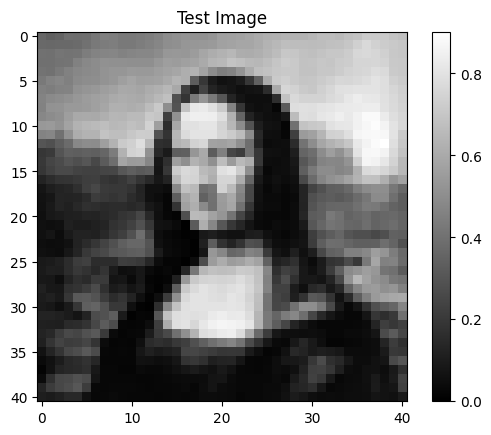

In [ ]:
test_img = appended_grid_input[:, :, 0, 10, 0].cpu().numpy() # Recovers Image - on the first 2 axes
# test_img = appended_grid_input[:, :, 1, 10, 0].cpu().numpy() # xvel yvel on the last 2 axes 
# test_img = grid_states[:, :, 0, 0, 2]
# test_img = last_grid[:, :, 0, 0, 0]
plt.imshow(test_img, cmap='gray')
plt.title("Test Image")
plt.colorbar()
plt.show()


flattened_grid_input shape:  torch.Size([1681, 3, 41, 41])


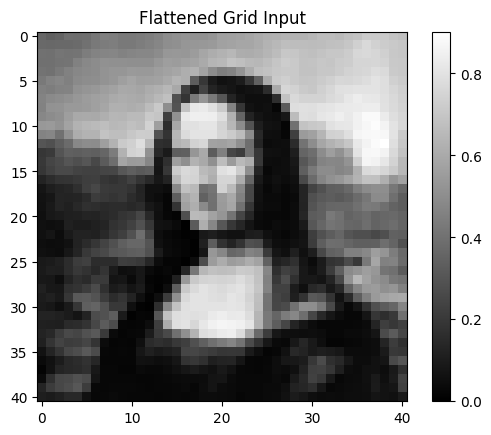

sum diff_xvel:  tensor(0.)
sum diff_yvel:  tensor(0.)


In [ ]:
flattened_grid_input = appended_grid_input.view(41, 41, 3, -1)
flattened_grid_input = flattened_grid_input.permute(3, 2, 0, 1)
print("flattened_grid_input shape: ", flattened_grid_input.shape)
plt.imshow(flattened_grid_input[0, 0, :, :].cpu().numpy(), cmap='gray')
plt.title("Flattened Grid Input")
plt.colorbar()
plt.show()

reshaped_grid_input = flattened_grid_input.permute(2, 3, 1, 0)
reshaped_grid_input = reshaped_grid_input.view(41, 41, 3, 41, 41)

grid_states_tensor = torch.from_numpy(grid_states)
diff_xvel = reshaped_grid_input[:, :, 1, :, :] - grid_states_tensor.permute(0, 1, 4, 2, 3)[:, :, 2, :, :]
diff_yvel = reshaped_grid_input[:, :, 2, :, :] - grid_states_tensor.permute(0, 1, 4, 2, 3)[:, :, 3, :, :]

print("sum diff_xvel: ", torch.sum(torch.abs(diff_xvel)))
print("sum diff_yvel: ", torch.sum(torch.abs(diff_yvel)))

# Test creating grid value function ?

In [ ]:
from torch.utils.data import DataLoader

from neuralop.models import FNO
from neuralop.data.datasets.tensor_dataset import TensorDataset

import sys 
sys.path.append('/home/jingpei/Documents/arclab/neuraloperator/safe_neural_operators')
from hjr_dataset import HJRDataset

In [ ]:
# Model parameters
model_dir = "/media/jingpei/DATA/fno_models/safe_neural-7-12-25"
save_dir = "/media/jingpei/DATA/fno_model_eval_results/fly_safe_neural-7-12-25"
device = "cuda:0"

# 1. Load the model "
model = FNO.from_checkpoint(save_folder=model_dir, save_name="model")
model = model.to(device)
model.eval()

# 2. Create dataset for now
data_root_dir = "/media/jingpei/DATA/fno_gp_data"
samples_for_train = 90
samples_for_test = 10 
datapoints_per_sample = 1000
batch_size = 128 #32
pre_sample_dataset = True 
encode_output = False 
encode_input = True 
encoding = "channel-wise"
dataset = HJRDataset(root_dir=data_root_dir, 
                    samples_for_train=samples_for_train, 
                    samples_for_test=samples_for_test, 
                    datapoints_per_sample=datapoints_per_sample,

                    batch_size=batch_size, 
                    pre_sample_dataset=pre_sample_dataset, 

                    encode_output=encode_output,
                    encode_input=encode_input,
                    encoding=encoding)

data_processor = dataset.data_processor

/home/jingpei/Documents/arclab/neuraloperator/safe_neural_operators/data_collection.py:106: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  grid_states = torch.load(grid_state

In [ ]:
# def get_gridvalue_function_from_model(disturbance_input, grid_states, model, data_processor):

# The inputs
disturbance_input = image_tensor
grid_states = grid_states 
model = model
data_processor = data_processor

"""
Gets the value function over the whole quad 2d grid (41, 41, 41, 41 ,4)

Arguments: 
- disturbance_input: (41, 41) image representing the disturbance magnitude 
- grid_states: (41, 41, 41, 41, 4) grid states of the quad2d system

Returns: 
- grid_value_function: (41, 41, 41, 41, 1) value function over the grid states to be used for CBF
"""
# NOTE: Temporary: need to change the input space to have full state so that you can use FNO as CBF directly - this needs changes! 

# 1. Get the grid inputs 
grid_states_tensor = torch.tensor(grid_states)
grid_resolution = grid_states_tensor.shape 

disturbance_input_tensor = torch.tensor(disturbance_input)
channel_dim = 1 + 1 # channel dim is 1 greater than the channel dim used for model training 
expanded_dims = list(grid_resolution[:-1])
expanded_dims.insert(channel_dim, 1)
grid_input = disturbance_input_tensor.view(grid_resolution[0], grid_resolution[1], 1, 1, 1)
grid_input = grid_input.expand(*expanded_dims)

# Inputs of the shape (batch_dim, channels, 41,41)
# Channels: [disturbance magnitude, grid xvel, grid yvel]
last_grid = grid_states_tensor[:, :, :, :, 2:]  # Last two channels are xvel and yvel
reorg_grid_channeldims = list(range(len(grid_resolution)))
last_dim_num = reorg_grid_channeldims.pop(-1)  # Remove last dim
reorg_grid_channeldims.insert(channel_dim, last_dim_num)  # Insert at channel_dim
last_grid = last_grid.permute(*reorg_grid_channeldims) 

# 2. Stack to create all the grid states # NOTE: HARDCODED FOR CHANNEL_DIM 1 / 2 here 
appended_grid_input = torch.cat((grid_input, last_grid), dim=channel_dim)
flattened_tensor_dataset = appended_grid_input.view(*appended_grid_input.shape[:3], -1) # (41, 41, 3, 41*41)
flattened_tensor_dataset = flattened_tensor_dataset.permute(3, 2, 0, 1)  # (batch_dim, channels, 41, 41)

# 3. Create tensor dataset to pass through the model 
test_db = TensorDataset(flattened_tensor_dataset, flattened_tensor_dataset[:, 0:1, :, :]) # y is placeholder
test_b_size = 128
test_loader = DataLoader(test_db, 
                        batch_size=test_b_size,
                        shuffle=False,
                        num_workers=1,
                        pin_memory=True,
                        persistent_workers=False,)

# 4. Go through the entire test dataloader and get the model output for each input and then stack them all together
with torch.no_grad():
    stacked_outputs = None 
    for idx, sample in enumerate(test_loader):
        sample = data_processor.preprocess(sample, batched=True)
        x = sample['x'].to(device)
        curr_model_output = model.forward(x)
        if stacked_outputs is None:
            stacked_outputs = curr_model_output.detach().cpu()
        else: 
            stacked_outputs = torch.cat((stacked_outputs, curr_model_output.detach().cpu()), dim=0)

# 5. Reshape the stacked outputs to the grid resolution # NOTE: HARDCODED FOR CHANNEL_DIM 1 / 2 here
grid_value_function = stacked_outputs.permute(2, 3, 1, 0)
grid_value_function = grid_value_function.view(grid_resolution[0], grid_resolution[1], *expanded_dims[2:]).squeeze(channel_dim)


/tmp/ipykernel_2988893/2901945522.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  disturbance_input_tensor = torch.tensor(disturbance_input)


flattened_tensor_dataset shape:  torch.Size([1681, 3, 41, 41])


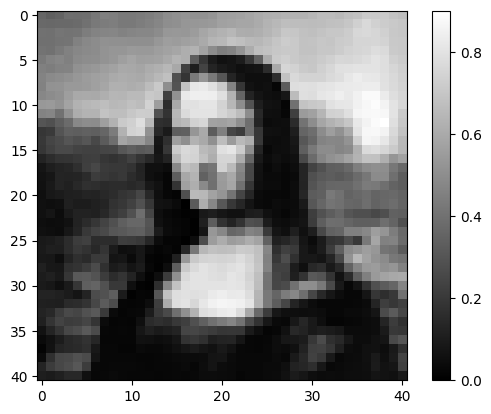

In [ ]:
print("flattened_tensor_dataset shape: ", flattened_tensor_dataset.shape)
plt.imshow(flattened_tensor_dataset[0, 0, :, :].cpu().numpy(), cmap='gray')
plt.colorbar()

torch.Size([17, 3, 41, 41])


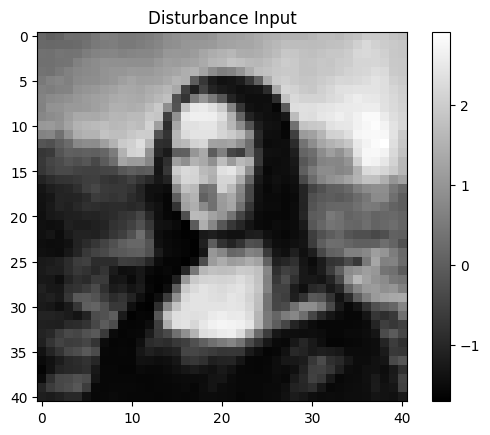

In [ ]:
print(x.shape)
plt.imshow(x[0, 0, :, :].cpu().numpy(), cmap='gray')
# plt.imshow(image_tensor.cpu().numpy(), cmap='gray')
plt.title("Disturbance Input")
plt.colorbar()  

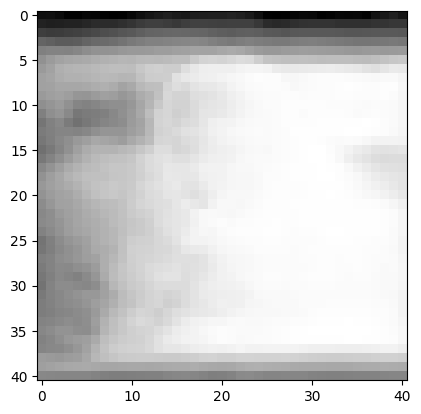

In [ ]:
plt.imshow(stacked_outputs.numpy()[10, 0, :, :], cmap='gray')